<a href="https://colab.research.google.com/github/Zuhair0000/tensorflow_bootcamp/blob/main/06_transfer_learning_in_tensorflow_part_3_scaling_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating helper function

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py



--2026-02-18 09:32:05--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-02-18 09:32:05 (117 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir

# Loading Data

In [3]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

unzip_data("101_food_classes_10_percent.zip")

train_dir = '/content/101_food_classes_10_percent/train'
test_dir = '/content/101_food_classes_10_percent/test'

--2026-02-18 09:32:14--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G   145MB/s    in 10s     

2026-02-18 09:32:25 (155 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [4]:
walk_through_dir('101_food_classes_10_percent')

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/creme_brulee'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/hot_dog'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pork_chop'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/prime_rib'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/takoyaki'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/carrot_cake'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/tiramisu'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/nachos'.
There are 0 directories and 75 images in '101_food_clas

In [5]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode='categorical',
                                                                 image_size=(224, 224))
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode='categorical',
                                                                image_size=(224, 224),
                                                                shuffle=False)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


# Model Checkpoint

In [9]:
checkpoint_path = '101_classes_10_percent_data_model_checkpoint.keras'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                        #  save_weights_only=True,
                                                         monitor='val_accuracy',
                                                         save_best_only=True)

In [14]:
from tensorflow.keras import layers

data_augmentaion = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomZoom(0.2),
], name='data_augmentation')

In [16]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

base_model.trainable=False

inputs = tf.keras.Input(shape=(224, 224, 3), name='input_layer')

x = data_augmentaion(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool_layers')(x)

outputs = tf.keras.layers.Dense(len(train_data.class_names), activation='softmax', name='output_layer')(x)

model = tf.keras.Model(inputs, outputs)

In [17]:
model.compile(loss='categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [19]:
history = model.fit(train_data,
                    steps_per_epoch=len(train_data),
                    epochs=5,
                    validation_data = test_data,
                    validation_steps=int(0.15 * len(test_data)),
                    callbacks=[checkpoint_callback])

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 107s 386ms/step - accuracy: 0.1300 - loss: 4.0663 - val_accuracy: 0.3501 - val_loss: 2.8155
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 73s 308ms/step - accuracy: 0.4016 - loss: 2.6126 - val_accuracy: 0.4436 - val_loss: 2.3115
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 73s 270ms/step - accuracy: 0.4813 - loss: 2.2076 - val_accuracy: 0.4748 - val_loss: 2.0975
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 59s 250ms/step - accuracy: 0.5107 - loss: 1.9880 - val_accuracy: 0.4891 - val_loss: 2.0405
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 54s 229ms/step - accuracy: 0.5488 - loss: 1.8289 - val_accuracy: 0.5185 - val_loss: 1.8850


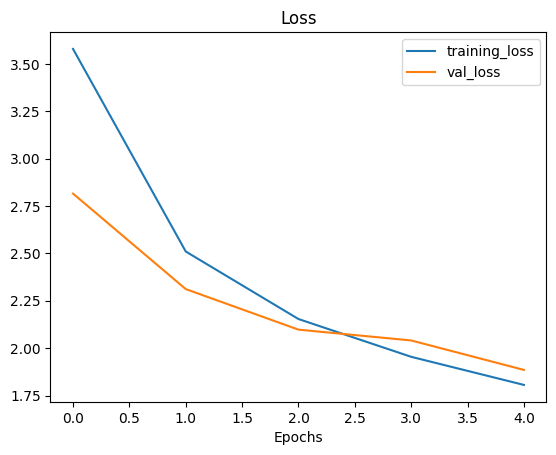

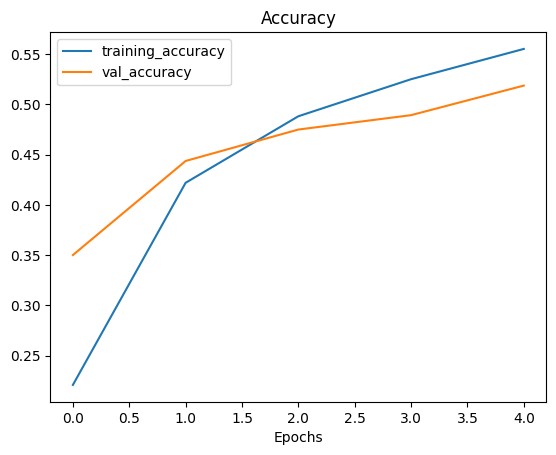

In [20]:
plot_loss_curves(history)

In [21]:
fine_tuning_results = model.evaluate(test_data)
fine_tuning_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 54s 68ms/step - accuracy: 0.5444 - loss: 1.7591


[1.6554025411605835, 0.5680792331695557]

In [24]:
base_model.trainable = True

for layer in base_model.layers[:-5]:
  layer.trainable=False

In [26]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [27]:
history_fine_tuning = model.fit(train_data,
                                steps_per_epoch=len(train_data),
                                epochs=10,
                                validation_data = test_data,
                                validation_steps=int(0.15 * len(test_data)),
                                initial_epoch=history.epoch[-1],
                                callbacks=[checkpoint_callback])

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 70s 242ms/step - accuracy: 0.5561 - loss: 1.9490 - val_accuracy: 0.5021 - val_loss: 2.0132
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 48s 203ms/step - accuracy: 0.5968 - loss: 1.7845 - val_accuracy: 0.5215 - val_loss: 1.9106
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.6083 - loss: 1.6852 - val_accuracy: 0.5265 - val_loss: 1.8609
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 80s 198ms/step - accuracy: 0.6181 - loss: 1.6127 - val_accuracy: 0.5397 - val_loss: 1.7934
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.6099 - loss: 1.5908 - val_accuracy: 0.5466 - val_loss: 1.7612
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 85s 190ms/step - accuracy: 0.6327 - loss: 1.5245 - val_accuracy: 0.5524 - val_loss: 1.7203


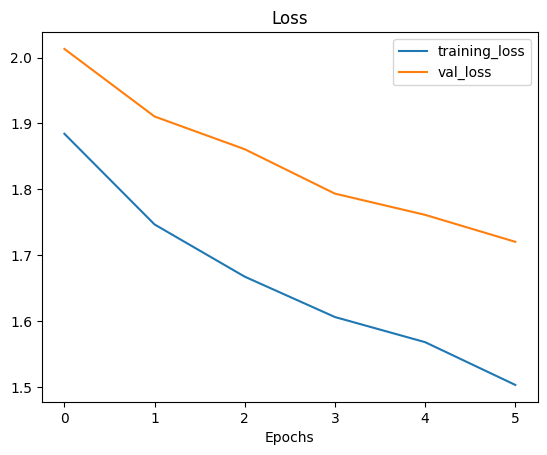

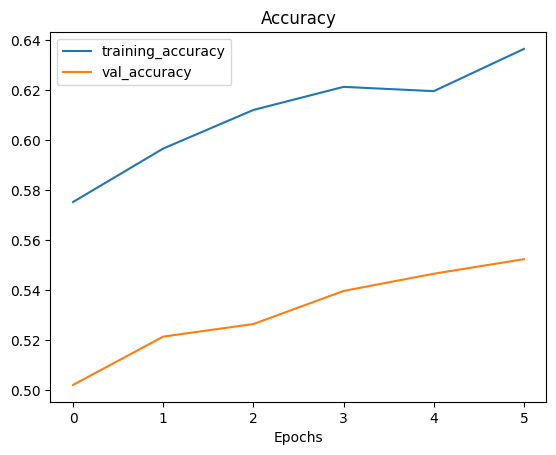

In [28]:
plot_loss_curves(history_fine_tuning)

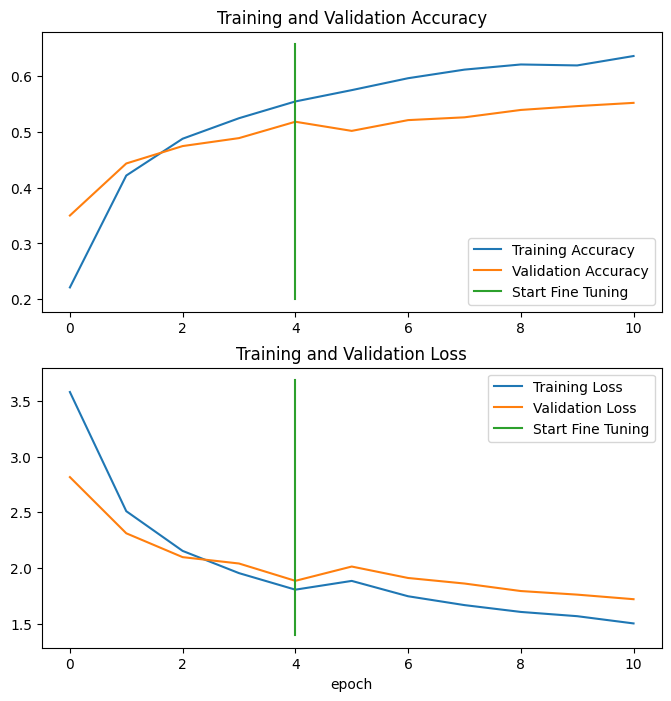

In [29]:
compare_historys(history, history_fine_tuning)